<a href="https://colab.research.google.com/github/Thiva02/Statistical-Learning-e22399/blob/main/Statistical_Learning_Assignement_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

**1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.**

In this model Assumed that point is uniformly distributed, sample space is proportional to the area.
* Total area of the disk: $Area_{total} = \pi R^2 = \pi(10)^2 = 100\pi$
* The event region;  $A$=  {The outer ring where $9 \le r \le 10$}
* $Area_{A} = \pi(10)^2 - \pi(9)^2 = 19\pi$
<p style="text-align: center;"> Probability $P(A) = \frac{Area_{A}}{Area_{total}} = \frac{19\pi}{100\pi} = 0.19$ </p>
<br>

**2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0, 10]$, and the direction is chosen independently and uniformly from $[0, 2\pi)$ and compute $P(A)$.**

In this model, the distance $r$ is a uniform random variable on the interval $[0, 10]$.
* Event $A$ occurs if $9 \le r \le 10$.
* The probability density function is $f(r) = \frac{1}{10}$.
* Probability $P(A) = P(9 \le r \le 10) = \frac{10 - 9}{10 - 0} = 0.1$
<br>

**3. Explain why the two answers differ.**

The two questions discussing fundamentally different random processes (a variation of Bertrand's paradox). In **Model 1 (Uniform Area)**, this model circumference increases with distance from the center, creating more area in the outer rings. In **Model 2 (Uniform Radius)**, the distance $r$ is chosen uniformly, meaning points are concentrated near the center compare to the available area, reducing the chance of landing in the outer ring.


--- Model 1: Uniform Area ---
Analytical P(A): 0.19
Simulated P(A):  0.1892

--- Model 2: Uniform Radius ---
Analytical P(A): 0.1
Simulated P(A):  0.0965



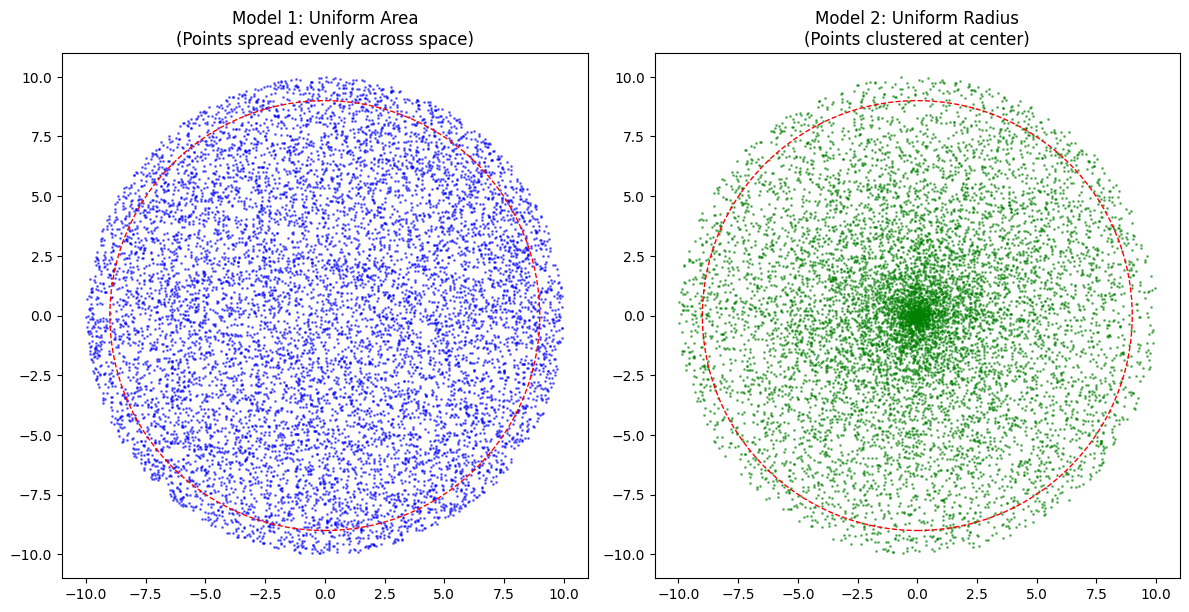

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
R = 10
inner_R = 9
N = 10000 # Number of points to simulate

# --- Model 1: Uniform Area ---
# To get a uniform distribution over the area, the radius must be scaled by the square root
r1 = R * np.sqrt(np.random.uniform(0, 1, N))
theta1 = np.random.uniform(0, 2*np.pi, N)

x1 = r1 * np.cos(theta1)
y1 = r1 * np.sin(theta1)

# Calculate simulated probability
prob1_sim = np.sum(r1 >= inner_R) / N
prob1_analytical = 19 / 100

print("--- Model 1: Uniform Area ---")
print(f"Analytical P(A): {prob1_analytical}")
print(f"Simulated P(A):  {prob1_sim:.4f}\n")


# --- Model 2: Uniform Radius ---
# Radius is uniformly distributed between 0 and 10
r2 = np.random.uniform(0, R, N)
theta2 = np.random.uniform(0, 2*np.pi, N)

x2 = r2 * np.cos(theta2)
y2 = r2 * np.sin(theta2)

# Calculate simulated probability
prob2_sim = np.sum(r2 >= inner_R) / N
prob2_analytical = 1 / 10

print("--- Model 2: Uniform Radius ---")
print(f"Analytical P(A): {prob2_analytical}")
print(f"Simulated P(A):  {prob2_sim:.4f}\n")


# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot Model 1
ax1.scatter(x1, y1, s=1, alpha=0.5, color='blue')
target_ring1 = plt.Circle((0, 0), inner_R, color='red', fill=False, linestyle='--')
ax1.add_patch(target_ring1)
ax1.set_xlim(-R-1, R+1)
ax1.set_ylim(-R-1, R+1)
ax1.set_aspect('equal')
ax1.set_title('Model 1: Uniform Area\n(Points spread evenly across space)')

# Plot Model 2
ax2.scatter(x2, y2, s=1, alpha=0.5, color='green')
target_ring2 = plt.Circle((0, 0), inner_R, color='red', fill=False, linestyle='--')
ax2.add_patch(target_ring2)
ax2.set_xlim(-R-1, R+1)
ax2.set_ylim(-R-1, R+1)
ax2.set_aspect('equal')
ax2.set_title('Model 2: Uniform Radius\n(Points clustered at center)')

plt.tight_layout()
plt.show()

# Q2) Bertrand's Paradox

Bertrand's paradox illustrates that the probability of a "random chord" being longer than the side of an inscribed equilateral triangle depends entirely on how we define "random." Let $R$ be the radius of the circle. The side length of an inscribed equilateral triangle is $s = R\sqrt{3}$. A chord is longer than $s$ if and only if its distance from the center is less than $R/2$.

Here are three mathematically natural models for choosing a random chord,

**Method 1: Random Endpoints**
*   **Model:** Choose two random, independent points uniformly on the circumference of the circle and draw a chord between them.
*   **Calculation:** Fix one point as a vertex of the inscribed triangle. For the chord to be longer than the triangle's side, the second point must fall on the arc between the other two vertices. The triangle divides the circumference into three equal arcs of $120^\circ$ (or $2\pi/3$).
*   **Probability:** The favorable arc is,
    $$P(L > s) = \frac{1}{3}$$

**Method 2: Random Radial Point**
*   **Model:** First Choose a random radius of the circle, then choose a point uniformly along that radius to be the midpoint of the chord. Draw the chord perpendicular to the radius at that point.
*   **Calculation:** The chord will be longer than the triangle's side if its midpoint is closer to the center than the side of the triangle is. The distance from the center to the side of the inscribed triangle is exactly $R/2$.
*   **Probability:** The midpoint must fall in the inner half of the radius $[0, R/2]$. Since the point is chosen uniformly along the radius $[0, R]$, the probability is,
  $$P(L > s) = \frac{R/2}{R} = \frac{1}{2}$$

**Method 3: Random Midpoint**
*   **Model:** Choose a point uniformly at random from the entire interior area of the circle to be the midpoint of the chord. Draw the chord perpendicular to the radius that passes through this midpoint.
*   **Calculation:** For the chord to be longer than the triangle's side, its midpoint must fall within a smaller concentric circle of radius $R/2$.
*   **Probability:** Since the point is chosen uniformly by area, the probability is the ratio of the area of the smaller circle to the area of the larger circle.
    $$P(L > s) = \frac{\pi (R/2)^2}{\pi R^2} = \frac{1}{4}$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
R = 1
N = 50000        # Number of samples for probability calculation
N_plot = 300     # Number of lines to draw in the plots

# Threshold distance for a chord to be longer than the triangle's side
d_threshold = R / 2

def calculate_chord_length(d, R):
    # L = 2 * sqrt(R^2 - d^2)
    return 2 * np.sqrt(np.maximum(0, R**2 - d**2))

# --- Method 1: Random Endpoints ---
theta1_m1 = np.random.uniform(0, 2*np.pi, N)
theta2_m1 = np.random.uniform(0, 2*np.pi, N)
# Distance from center is R * |cos((theta1 - theta2) / 2)|
d_m1 = R * np.abs(np.cos((theta1_m1 - theta2_m1) / 2))
prob_m1 = np.sum(d_m1 < d_threshold) / N

# --- Method 2: Random Radial Point ---
# Distance is uniformly distributed between 0 and R
d_m2 = np.random.uniform(0, R, N)
prob_m2 = np.sum(d_m2 < d_threshold) / N

# --- Method 3: Random Midpoint ---
# To get uniform area distribution, r = R * sqrt(U)
d_m3 = R * np.sqrt(np.random.uniform(0, 1, N))
prob_m3 = np.sum(d_m3 < d_threshold) / N

# --- Print Results ---
print(f"Method 1 (Random Endpoints) Simulated Prob: {prob_m1:.4f} (Expected: 0.3333)")
print(f"Method 2 (Random Radial Point) Simulated Prob: {prob_m2:.4f} (Expected: 0.5000)")
print(f"Method 3 (Random Midpoint) Simulated Prob: {prob_m3:.4f} (Expected: 0.2500)\n")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ['Method 1: Random Endpoints\n(Concentrated near edges)',
          'Method 2: Random Radial Point\n(Evenly distributed)',
          'Method 3: Random Midpoint\n(Concentrated near center)']

# Function to plot a circle and inscribed triangle
def draw_base(ax):
    circle = plt.Circle((0, 0), R, color='black', fill=False, linewidth=2)
    ax.add_patch(circle)
    inner_circle = plt.Circle((0, 0), R/2, color='red', fill=False, linestyle='--', linewidth=1.5)
    ax.add_patch(inner_circle)
    ax.set_xlim(-R-0.1, R+0.1)
    ax.set_ylim(-R-0.1, R+0.1)
    ax.set_aspect('equal')
    ax.axis('off')

# Plot Method 1
draw_base(axes[0])
for i in range(N_plot):
    x_vals = [R * np.cos(theta1_m1[i]), R * np.cos(theta2_m1[i])]
    y_vals = [R * np.sin(theta1_m1[i]), R * np.sin(theta2_m1[i])]
    axes[0].plot(x_vals, y_vals, color='blue', alpha=0.15)
axes[0].set_title(titles[0])

# Plot Method 2
draw_base(axes[1])
theta_m2 = np.random.uniform(0, 2*np.pi, N_plot)
for i in range(N_plot):
    d = d_m2[i]
    angle = theta_m2[i]
    half_L = np.sqrt(R**2 - d**2)
    # Midpoint coordinates
    mx, my = d * np.cos(angle), d * np.sin(angle)
    # Tangent vector
    tx, ty = -np.sin(angle), np.cos(angle)
    axes[1].plot([mx - half_L*tx, mx + half_L*tx],
                 [my - half_L*ty, my + half_L*ty], color='green', alpha=0.15)
axes[1].set_title(titles[1])

# Plot Method 3
draw_base(axes[2])
theta_m3 = np.random.uniform(0, 2*np.pi, N_plot)
for i in range(N_plot):
    d = d_m3[i]
    angle = theta_m3[i]
    half_L = np.sqrt(R**2 - d**2)
    mx, my = d * np.cos(angle), d * np.sin(angle)
    tx, ty = -np.sin(angle), np.cos(angle)
    axes[2].plot([mx - half_L*tx, mx + half_L*tx],
                 [my - half_L*ty, my + half_L*ty], color='purple', alpha=0.15)
axes[2].set_title(titles[2])

plt.tight_layout()
plt.show()

# Q8) Probability of Being a Girl?

**Problem:** A family has two children. Assume each child is equally likely to be a boy (B) or a girl (G). What is the probability that both children are girls, given that **at least one** of them is a girl?

## Theoretical Solution:

the expected events here is:

**Sample Space ($\Omega$):** The possible outcomes for two children:
*   `BB` (Boy, Boy)
*   `BG` (Boy, Girl)
*   `GB` (Girl, Boy)
*   `GG` (Girl, Girl)
<br>    Each outcome has a probability of $1/4$.

**The Condition ($C$):** Given that *at least one* child is a girl:
    $$C = \{BG, GB, GG\}$$
    There are 3 equally likely outcomes in this restricted sample space. This is the new sample space

<br>

**The Event of Interest (Event $A$):** The probability that *both* children are girls. in our new sample space $C$:
  $$A \cap C = \{GG\}$$

<br>

**Calculating Conditional Probability:** Using the formula for conditional probability, $P(A|C) = \frac{P(A \cap C)}{P(C)}$:
  $$P(\text{Both Girls | At Least One Girl}) = \frac{\text{Number of outcomes in } (A \cap C)}{\text{Number of outcomes in } C} = \frac{1}{3}$$

The probability is **$1/3$** (approximately 0.3333).



In [ ]:
import numpy as np

# --- Parameters ---
N = 1000000  # Number of simulated families

# --- Simulation ---
# Simulate families with 2 children
# Let 0 = Boy, 1 = Girl
child1 = np.random.choice([0, 1], size=N)
child2 = np.random.choice([0, 1], size=N)

# Apply the condition: We only care about families with at least one girl
at_least_one_girl_mask = (child1 == 1) | (child2 == 1)

# Filter the arrays to keep only the valid families
filtered_child1 = child1[at_least_one_girl_mask]
filtered_child2 = child2[at_least_one_girl_mask]

# Among these filtered families, count how many have TWO girls
both_girls_mask = (filtered_child1 == 1) & (filtered_child2 == 1)
total_both_girls = np.sum(both_girls_mask)

# Calculate simulated probability
total_valid_families = len(filtered_child1)
simulated_prob = total_both_girls / total_valid_families

# --- Results ---
print(f"Total families initially simulated: {N:,}")
print(f"Families meeting the condition (at least one girl): {total_valid_families:,}")
print(f"Families meeting the condition AND having two girls: {total_both_girls:,}\n")

print(f"Theoretical Probability: 1/3 (approx. 0.3333)")
print(f"Simulated Probability:   {simulated_prob:.4f}")

# Q9) Information Available in a Discrete Random Variable

**1. Write down the probability space $(\Omega, \mathfrak{F}, P)$, where $\mathfrak{F} = \mathfrak{P}(\Omega)$:**
*   **Sample Space ($\Omega$):** $\Omega = \{G_1, G_2, D_1, D_2\}$

*   **$\sigma$-algebra ($\mathfrak{F}$):** Since $\mathfrak{F}$ is the power set $\mathfrak{P}(\Omega)$, it contains all $2^4 = 16$ possible subsets of $\Omega$:
  $\mathfrak{F} = \{\emptyset, \{G_1\}, \{G_2\}, \{D_1\}, \{D_2\}, \{G_1, G_2\}, \{G_1, D_1\}, \{G_1, D_2\}, \{G_2, D_1\}, \{G_2, D_2\}, \{D_1, D_2\}, \{G_1, G_2, D_1\}, \{G_1, G_2, D_2\}, \{G_1, D_1, D_2\}, \{G_2, D_1, D_2\}, \Omega\}$

*   **Probability Measure ($P$):** Defined by summing the probabilities of the outcomes in any given set $A \in \mathfrak{F}$, based on the fundamental probabilities: $P(\{G_1\}) = 0.50$, $P(\{G_2\}) = 0.20$, $P(\{D_1\}) = 0.10$, $P(\{D_2\}) = 0.20$.

**2. Compute the $\sigma$-algebra generated by $X$:**<br>
The random variable $X$ partitions the sample space into sets where $X$ is constant: $\{X=0\} = \{G_1, G_2\}$ and $\{X=1\} = \{D_1, D_2\}$.
The $\sigma$-algebra generated by $X$ is,
$$ \sigma(X) = \{\emptyset, \{G_1, G_2\}, \{D_1, D_2\}, \Omega\} $$


**3. Compute the $\sigma$-algebra generated by $Y$:**<br>
The random variable $Y$ assigns a unique value to every single outcome in the sample space. Therefore, the pre-images of $Y$ are the singleton sets: $\{G_1\}, \{G_2\}, \{D_1\}, \{D_2\}$. A $\sigma$-algebra containing all singletons of a finite set must be the power set.
$$ \sigma(Y) = \mathfrak{P}(\Omega) $$

**4. Show that $\sigma(X) \subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$:**
<br>
Looking at our answers above, every element in $\sigma(X)$ (which are $\emptyset, \{G_1, G_2\}, \{D_1, D_2\}, \Omega$) is also present in $\sigma(Y)$ (the power set). Thus, $\sigma(X) \subseteq \sigma(Y)$.
**Explanation:** $Y$ contains more information because knowing the value of $Y$ tells you exactly which outcome occurred. Knowing $X$ only tells you the quality, grouping the machines together and leaving uncertainty about the exact origin. A finer partition leads to a larger $\sigma$-algebra, reflecting more detailed information.

**5. Find the marginal distribution of $X$:**
*   $P(X=0) = P(\{G_1, G_2\}) = P(G_1) + P(G_2) = 0.50 + 0.20 = 0.70$
*   $P(X=1) = P(\{D_1, D_2\}) = P(D_1) + P(D_2) = 0.10 + 0.20 = 0.30$

**6. Find the marginal distribution of $Y$:**
*   $P(Y=1) = P(G_1) = 0.50$
*   $P(Y=2) = P(G_2) = 0.20$
*   $P(Y=3) = P(D_1) = 0.10$
*   $P(Y=4) = P(D_2) = 0.20$

**7. Compute the joint probabilities:**
Because $Y$ completely determines $X$, the joint probabilities are just the probabilities of specific elements in $\Omega$:
*   $P(X=0, Y=1) = P(\{G_1\}) = 0.50$
*   $P(X=0, Y=2) = P(\{G_2\}) = 0.20$
*   $P(X=1, Y=3) = P(\{D_1\}) = 0.10$
*   $P(X=1, Y=4) = P(\{D_2\}) = 0.20$

**8. Compute the conditional probabilities:**<br><br>
Using the formula $P(A|B) = P(A \cap B) / P(B)$:
*   $P(X=1 | Y=3) = \frac{P(X=1, Y=3)}{P(Y=3)} = \frac{0.10}{0.10} = 1$
*   $P(X=1 | Y=4) = \frac{P(X=1, Y=4)}{P(Y=4)} = \frac{0.20}{0.20} = 1$
*   $P(Y=3 | X=1) = \frac{P(X=1, Y=3)}{P(X=1)} = \frac{0.10}{0.30} = \frac{1}{3} \approx 0.333$
*   $P(Y=4 | X=1) = \frac{P(X=1, Y=4)}{P(X=1)} = \frac{0.20}{0.30} = \frac{2}{3} \approx 0.667$

**9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.**
Conditioning on $Y$ removes all uncertainty about $X$. If you know which machine produced the item and its quality (Y), you fundamentally know its quality (X). However, conditioning on $X$ leaves uncertainty about $Y$. If you only know an item is defective ($X=1$), still don't know for sure whether Machine 1 or Machine 2 produced it.

**10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and vice versa:**
*   **Information in $\sigma(X)$ but not in $\sigma(Y)$:** None. Because $\sigma(X) \subseteq \sigma(Y)$, every event that is measurable by $X$ is also measurable by $Y$. In conclution, $Y$ knows everything $X$ knows.
*   **Information in $\sigma(Y)$ but not in $\sigma(X)$:** The specific machine origin. The sigma-algebra $\sigma(Y)$ can tell whether an item was produced by Machine 1 or Machine 2, while $\sigma(X)$ treats them the same and only reflects information about their quality.

--- Q12: Shannon Entropy Results ---
Marginal Entropy H(X):     0.8813 bits
Marginal Entropy H(Y):     1.7610 bits
Joint Entropy H(X,Y):      1.7610 bits
Conditional H(X|Y):        0.0000 bits (No uncertainty in X if Y is known)
Conditional H(Y|X):        0.8797 bits (Remaining uncertainty about Machine given Quality)
----------------------------------------


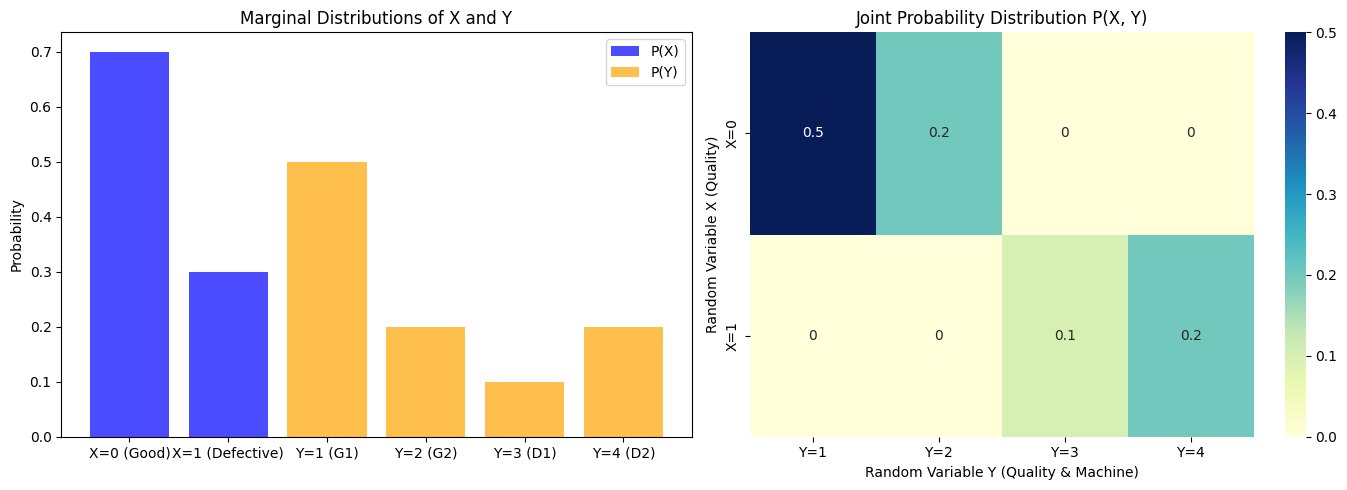

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Define the Probability Space ---
outcomes = ['G1', 'G2', 'D1', 'D2']
probs = np.array([0.50, 0.20, 0.10, 0.20])

# Marginals
P_X = np.array([0.70, 0.30]) # X=0, X=1
P_Y = probs.copy()           # Y=1, 2, 3, 4

# Joint Distribution P(X,Y) Matrix
# Rows are X (0, 1), Columns are Y (1, 2, 3, 4)
P_XY = np.array([
    [0.50, 0.20, 0.00, 0.00],  # X=0 (Good)
    [0.00, 0.00, 0.10, 0.20]   # X=1 (Defective)
])

# --- Q12: Shannon Entropy Calculations ---
# Formula: H = - sum(p * log2(p)) for p > 0

def calc_entropy(p_array):
    p_nonzero = p_array[p_array > 0]
    return -np.sum(p_nonzero * np.log2(p_nonzero))

# Marginal Entropies
H_X = calc_entropy(P_X)
H_Y = calc_entropy(P_Y)

# Joint Entropy
H_XY = calc_entropy(P_XY)

# Conditional Entropies: H(A|B) = H(A,B) - H(B)
H_X_given_Y = H_XY - H_Y
H_Y_given_X = H_XY - H_X

print("--- Q12: Shannon Entropy Results ---")
print(f"Marginal Entropy H(X):     {H_X:.4f} bits")
print(f"Marginal Entropy H(Y):     {H_Y:.4f} bits")
print(f"Joint Entropy H(X,Y):      {H_XY:.4f} bits")
print(f"Conditional H(X|Y):        {H_X_given_Y:.4f} bits (No uncertainty in X if Y is known)")
print(f"Conditional H(Y|X):        {H_Y_given_X:.4f} bits (Remaining uncertainty about Machine given Quality)")
print("-" * 40)

# --- Q11: Python Based Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Marginals as Bar Charts
x_labels = ['X=0 (Good)', 'X=1 (Defective)']
y_labels = ['Y=1 (G1)', 'Y=2 (G2)', 'Y=3 (D1)', 'Y=4 (D2)']

axes[0].bar(x_labels, P_X, alpha=0.7, label='P(X)', color='blue')
axes[0].bar(y_labels, P_Y, alpha=0.7, label='P(Y)', color='orange')
axes[0].set_title('Marginal Distributions of X and Y')
axes[0].set_ylabel('Probability')
axes[0].legend()

# 2. Plot Joint Distribution as a Heatmap
sns.heatmap(P_XY, annot=True, cmap="YlGnBu", ax=axes[1], cbar=True,
            xticklabels=['Y=1', 'Y=2', 'Y=3', 'Y=4'],
            yticklabels=['X=0', 'X=1'])
axes[1].set_title('Joint Probability Distribution P(X, Y)')
axes[1].set_xlabel('Random Variable Y (Quality & Machine)')
axes[1].set_ylabel('Random Variable X (Quality)')

plt.tight_layout()
plt.show()

# Q10) Information Available in Continuous Random Variables

**1. Write down the probability space $(\Omega, \mathfrak{F}, P)$ explicitly:**
*   **Sample Space ($\Omega$):** $\Omega = \mathbb{R}^2$ (representing all possible pairs of temperature and pressure deviations).
*   **$\sigma$-algebra ($\mathfrak{F}$):** $\mathfrak{F} = \mathfrak{B}(\mathbb{R}^2)$, the Borel $\sigma$-algebra on $\mathbb{R}^2$.
*   **Probability Measure ($P$):** Defined by the joint density function thats given:
    $$P(A) = \iint_A \frac{1}{4\pi} \exp\left(-\frac{t^2}{2} - \frac{p^2}{8}\right) dt \, dp \quad \text{for any } A \in \mathfrak{B}(\mathbb{R}^2)$$
<br>

**2. Compute the $\sigma$-algebra generated by $X$:**<br>
The random variable $X(t,p) = t$ projects the 2D space onto the 1D temperature axis. The $\sigma$-algebra generated by $X$ consists of the pre-images of all Borel sets $B \in \mathfrak{B}(\mathbb{R})$.
$$ \sigma(X) = \{B \times \mathbb{R} \mid B \in \mathfrak{B}(\mathbb{R})\} $$
Visually, these are vertical "strips" in the $(t,p)$ plane.
<br>

**3. Compute the $\sigma$-algebra generated by $Y$:**<br>
The random variable $Y(t,p) = (t,p)$ is the identity mapping on $\mathbb{R}^2$. Therefore, it can distinguish every individual point and Borel set in the space.
$$ \sigma(Y) = \mathfrak{B}(\mathbb{R}^2) $$
<br>

**4. Show that $\sigma(X) \subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$:**<br>
Take any set in $\sigma(X)$, which has the form $B \times \mathbb{R}$. Since $B$ is a Borel set in $\mathbb{R}$, the Cartesian product $B \times \mathbb{R}$ is a Borel set in $\mathbb{R}^2$. Therefore, it belongs to $\mathfrak{B}(\mathbb{R}^2)$, which is $\sigma(Y)$. This proves $\sigma(X) \subseteq \sigma(Y)$.
**Explanation:** $Y$ contains more information because it records the exact state of both temperature and pressure. $X$ only records temperature, effectively throwing away the pressure data.
<br>

**5. Find the marginal density of $X$:**
Since $X$ just extracts $T$, and $T$ and $P$ are independent, $X \sim N(0, 1)$.
$$ f_X(x) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{x^2}{2}\right) $$
<br>

**6. Find the marginal density of $Y$:**<br>
Since $Y = (T,P)$, its marginal density is simply the joint density of $T$ and $P$.
$$ f_Y(t,p) = f_{T,P}(t,p) = \frac{1}{4\pi} \exp\left(-\frac{t^2}{2} - \frac{p^2}{8}\right) $$
<br>

**7. Compute the following probabilities:**<br>
Let $\Phi$ be the CDF of the standard normal distribution.
*   $P(X \leq 0)$: Since $X \sim N(0,1)$, which is symmetric around 0, **$P(X \leq 0) = 0.5$**.
*   $P(X > 1)$: $1 - \Phi(1) \approx 1 - 0.8413 = \textbf{0.1587}$.
*   $P(Y \in (-\infty, 0] \times \mathbb{R})$: This is exactly $P(T \leq 0 \text{ and } P \in \mathbb{R}) = P(T \leq 0) = \textbf{0.5}$.
*   $P(Y \in [-1, 1] \times [-2, 2])$: Because $T$ and $P$ are independent:
  $= P(-1 \leq T \leq 1) \times P(-2 \leq P \leq 2)$
  Note that $P \sim N(0, 4)$, so its standard deviation is 2. Thus, $P/2 \sim N(0, 1)$.
  $= P(-1 \leq T \leq 1) \times P(-1 \leq P/2 \leq 1) = (\Phi(1) - \Phi(-1))^2 \approx (0.6827)^2 \approx \textbf{0.466}$.
<br>

**8. Compute the conditional distribution of $X$ given $Y = (t,p)$:**<br>
If we know $Y=(t,p)$, we know exactly that the temperature is $t$ and pressure is $p$. There is no randomness left for $X$. The conditional distribution is a deterministic point mass (Dirac delta) at $t$:
$$ P(X = x \mid Y = (t,p)) = \begin{cases} 1 & \text{if } x = t \\ 0 & \text{otherwise} \end{cases} $$
<br>

**9. Compute the conditional distribution of $Y$ given $X = t$:**<br>
Given $X=t$, we know $T=t$. Since $T$ and $P$ are independent, knowing $T$ tells us nothing new about $P$. So, $P$ remains distributed as $N(0, 4)$. The conditional distribution of $Y$ lies strictly on the vertical line $T=t$, with the density along that line given by the normal distribution of $P$:
$$ f_{Y|X}(t', p' \mid t) = \delta(t' - t) \frac{1}{\sqrt{8\pi}} \exp\left(-\frac{p'^2}{8}\right) $$
<br>

**10. Explain what is known when one conditions on $X$ vs $Y$:**
*   **Conditioning on $X$:** We know the exact temperature deviation, but the pressure deviation remains completely unknown (it retains its prior $N(0,4)$ uncertainty).
*   **Conditioning on $Y$:** We know the exact state of the entire system (both temperature and pressure). Zero uncertainty remains.
<br>

**11. Show that $X = \pi_1 \circ Y$:**<br>
Let $\pi_1(t,p) = t$ be the projection onto the first coordinate.
$$ (\pi_1 \circ Y)(t,p) = \pi_1(Y(t,p)) = \pi_1(t,p) = t = X(t,p) $$
**Why this implies $X$ is measurable wrt $Y$:** The function $\pi_1$ is a continuous function. The composition of measurable functions is measurable. Since $X$ can be written purely as a function of $Y$, any information in $X$ is entirely derivable from $Y$, conclude that $\sigma(X) \subseteq \sigma(Y)$.
<br>

**13. Compute the differential entropy of $X$.**
The differential entropy for a Gaussian $N(\mu, \sigma^2)$ is $h = \frac{1}{2} \ln(2\pi e \sigma^2)$. Here $X \sim N(0, 1)$, so $\sigma^2 = 1$.
$$ h(X) = \frac{1}{2} \ln(2\pi e (1)) = \frac{1}{2} \ln(2\pi e) \text{ nats} $$
<br>

**14. Compute the differential entropy of $Y$.**
Because $T$ and $P$ are independent, $h(Y) = h(T) + h(P)$.
$P \sim N(0, 4)$, so $\sigma^2 = 4$. $h(P) = \frac{1}{2}\ln(2\pi e (4)) = \frac{1}{2}\ln(8\pi e)$.
$$ h(Y) = \frac{1}{2} \ln(2\pi e) + \frac{1}{2} \ln(8\pi e) = \frac{1}{2} \ln(16\pi^2 e^2) = \ln(4\pi e) \text{ nats} $$
<br>

**15. Compute the conditional differential entropy $h(Y|X)$, and interpret it:**
$$ h(Y|X) = h(Y) - h(X) = \ln(4\pi e) - \frac{1}{2}\ln(2\pi e) = \frac{1}{2}\ln(8\pi e) $$
*(Alternatively, since independent, $h(Y|X) = h(T,P|T) = h(P)$).*
**Physical Interpretation:** This is the remaining uncertainty in the reactor system after the temperature $X$ is measured. Since temperature and pressure are independent, measuring temperature reduces the total system uncertainty by exactly the entropy of the temperature, leaving only the uncertainty of the pressure.
<br>

**16. Discuss what happens to $h(X|Y)$:**<br>
Since $Y$ completely determines $X$, the conditional variance of $X$ given $Y$ is 0. For continuous variables, as the probability density concentrates into a Dirac delta function (a spike of zero width), the differential entropy approaches $-\infty$.
**Explanation:** Unlike discrete entropy, continuous differential entropy can be negative. It represents relative volume. A completely determined continuous variable has a "volume" of zero, and $\ln(0) \to -\infty$. It implies we have "infinite precision" information about $X$ when $Y$ is known.

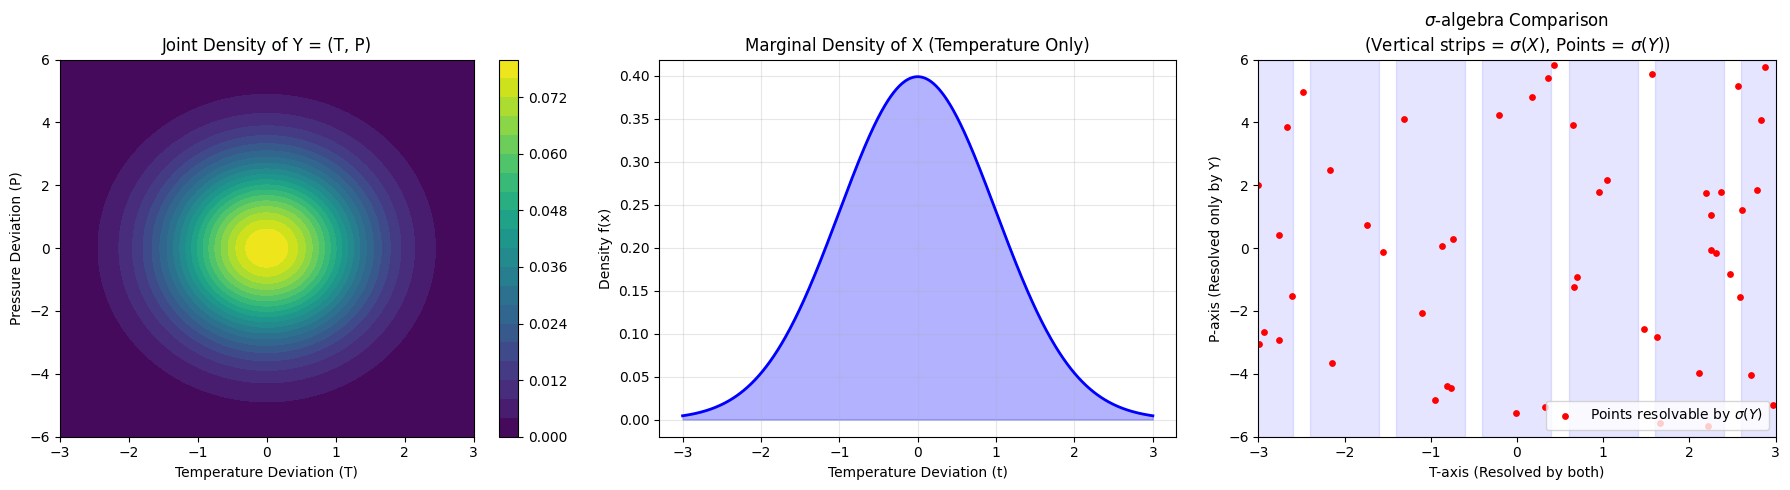

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Data Preparation ---
# Grid for T (temperature) and P (pressure)
t = np.linspace(-3, 3, 500)
p = np.linspace(-6, 6, 500)
T, P = np.meshgrid(t, p)

# Densities
# T ~ N(0, 1)
f_T = norm.pdf(t, loc=0, scale=1)
# P ~ N(0, 4), meaning standard deviation is 2
f_P = norm.pdf(P, loc=0, scale=2)
# Joint Density Y = (T, P)
f_Y = norm.pdf(T, loc=0, scale=1) * norm.pdf(P, loc=0, scale=2)

# --- Visualization ---
fig = plt.figure(figsize=(18, 5))

# 1. Joint Density of Y as a Contour Plot
ax1 = fig.add_subplot(131)
contour = ax1.contourf(T, P, f_Y, levels=20, cmap='viridis')
fig.colorbar(contour, ax=ax1)
ax1.set_title('Joint Density of Y = (T, P)')
ax1.set_xlabel('Temperature Deviation (T)')
ax1.set_ylabel('Pressure Deviation (P)')

# 2. Marginal Density of X
ax2 = fig.add_subplot(132)
ax2.plot(t, f_T, color='blue', linewidth=2)
ax2.fill_between(t, f_T, alpha=0.3, color='blue')
ax2.set_title('Marginal Density of X (Temperature Only)')
ax2.set_xlabel('Temperature Deviation (t)')
ax2.set_ylabel('Density f(x)')
ax2.grid(True, alpha=0.3)

# 3. Diagram illustrating sigma-algebras
ax3 = fig.add_subplot(133)
# To show sigma(X) is coarser, we represent it as vertical strips (it only resolves X axis)
for i in range(-3, 4):
    ax3.axvspan(i-0.4, i+0.4, color='blue', alpha=0.1)

# To show sigma(Y) is finer, we show it resolves specific points/grids in 2D space
# FIXED: Added 'r' before the string to handle the backslash in LaTeX
ax3.scatter(np.random.uniform(-3, 3, 50), np.random.uniform(-6, 6, 50),
            color='red', s=15, label=r'Points resolvable by $\sigma(Y)$')

ax3.set_xlim(-3, 3)
ax3.set_ylim(-6, 6)
# FIXED: Used double backslashes (\\) for LaTeX symbols since there is a newline (\n) character
ax3.set_title('$\\sigma$-algebra Comparison\n(Vertical strips = $\\sigma(X)$, Points = $\\sigma(Y)$)')
ax3.set_xlabel('T-axis (Resolved by both)')
ax3.set_ylabel('P-axis (Resolved only by Y)')
ax3.legend(loc='lower right')

plt.tight_layout()
plt.show()